In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def make_labelled_DAG(df_effects, df_edges):
    g = nx.DiGraph(df_edges)
    edges = g.edges()

    pos={
            "stroke_severity_mild":(1,3),
            "stroke_severity_moderate":(2,2.5),
            "stroke_severity_severe":(3,3),
            "age_80plus":(7,3),
            "prior_util":(7,2),
            "atrial_fibrillation":(6,3),
            "afib_anticoagulant":(6,2),
            "onset_during_sleep":(5,3),
            "precise_onset_known":(5,2),
            "arrival_to_scan_time":(4,2),
            "thrombolysis":(3.5,1),
            "discharge_mrsleq2":(3.5,0)
            }

    labels = []
    for start_node, end_node in edges:
        edge_effect = df_effects.loc[start_node, end_node]
        label = f'{edge_effect:.2f}'  
        labels.append(label)
    labels = dict(zip(edges, labels)) 

    node_size = 1200

    fig, ax = plt.subplots(figsize=(15,10))

    nx.draw_networkx_nodes(g, pos, node_size=node_size, ax=ax)
    nx.draw_networkx_labels(g, pos, font_size=10, ax=ax) 

    nx.draw_networkx_edges(
        g, pos,
        node_size=node_size,
        ax=ax
    )

    nx.draw_networkx_edge_labels(
        g,
        pos,
        labels,
        label_pos=0.3, 
        ax=ax,
    )

In [3]:
file= "effects_linreg_allpatients_mrsleq2"
df_effects = pd.read_csv (f"{file}.csv", index_col=0)
df_effects = df_effects.drop(["discharge_util"], axis=1)
df_effects = df_effects.drop(["discharge_util"], axis=0)

In [4]:
df_effects.index = [str(d) for d in df_effects.index]
team_rows = df_effects.index[df_effects.index.str.isnumeric()]
team_rows

Index(['2', '3', '5', '6', '7', '8', '9', '11', '12', '13', '14', '18', '20',
       '21', '24', '25', '28', '29', '31', '32', '33', '34', '36', '38', '39',
       '40', '42', '43', '45', '47', '48', '49', '51', '55', '56', '58', '60',
       '61', '62', '65', '66', '68', '70', '71', '72', '73', '74', '76', '77',
       '78', '80', '82', '83', '85', '87', '93', '94', '95', '98', '99', '100',
       '103', '104', '106', '107', '108'],
      dtype='str')

In [5]:
df_effects = df_effects.drop(team_rows, axis=0)
df_effects

,precise_onset_known,afib_anticoagulant,prior_util,arrival_to_scan_time,thrombolysis,discharge_mrsleq2
onset_during_sleep,-0.65821,NaN,NaN,NaN,-0.12155,NaN
precise_onset_known,NaN,NaN,NaN,NaN,0.13737,NaN
atrial_fibrillation,NaN,0.63438,NaN,NaN,NaN,-0.02420
afib_anticoagulant,NaN,NaN,NaN,NaN,-0.29834,NaN
prior_util,NaN,NaN,NaN,NaN,0.32325,0.77955
age_80plus,NaN,NaN,-0.11836,NaN,-0.01555,-0.14663
stroke_severity_mild,NaN,NaN,NaN,NaN,-0.07235,0.18851
stroke_severity_moderate,NaN,NaN,NaN,NaN,0.18370,-0.14345
stroke_severity_severe,NaN,NaN,NaN,NaN,-0.04330,-0.29924
arrival_to_scan_time,NaN,NaN,NaN,NaN,-0.00177,NaN


In [6]:
index_list=df_effects.index
index_list

Index(['onset_during_sleep', 'precise_onset_known', 'atrial_fibrillation',
       'afib_anticoagulant', 'prior_util', 'age_80plus',
       'stroke_severity_mild', 'stroke_severity_moderate',
       'stroke_severity_severe', 'arrival_to_scan_time', 'thrombolysis',
       'discharge_mrsleq2', 'const'],
      dtype='str')

In [7]:
columns_list=df_effects.columns
columns_list

Index(['precise_onset_known', 'afib_anticoagulant', 'prior_util',
       'arrival_to_scan_time', 'thrombolysis', 'discharge_mrsleq2'],
      dtype='str')

In [8]:
for i in index_list:
    if i not in columns_list:
        df_effects[i]=np.nan

In [9]:
df_effects = df_effects.drop(["const"], axis=1)
df_effects = df_effects.drop(["const"], axis=0)

In [10]:
df_effects
#the left is what is meant to affect the top

,precise_onset_known,afib_anticoagulant,prior_util,arrival_to_scan_time,thrombolysis,discharge_mrsleq2,onset_during_sleep,atrial_fibrillation,age_80plus,stroke_severity_mild,stroke_severity_moderate,stroke_severity_severe
onset_during_sleep,-0.65821,NaN,NaN,NaN,-0.12155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precise_onset_known,NaN,NaN,NaN,NaN,0.13737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atrial_fibrillation,NaN,0.63438,NaN,NaN,NaN,-0.02420,NaN,NaN,NaN,NaN,NaN,NaN
afib_anticoagulant,NaN,NaN,NaN,NaN,-0.29834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prior_util,NaN,NaN,NaN,NaN,0.32325,0.77955,NaN,NaN,NaN,NaN,NaN,NaN
age_80plus,NaN,NaN,-0.11836,NaN,-0.01555,-0.14663,NaN,NaN,NaN,NaN,NaN,NaN
stroke_severity_mild,NaN,NaN,NaN,NaN,-0.07235,0.18851,NaN,NaN,NaN,NaN,NaN,NaN
stroke_severity_moderate,NaN,NaN,NaN,NaN,0.18370,-0.14345,NaN,NaN,NaN,NaN,NaN,NaN
stroke_severity_severe,NaN,NaN,NaN,NaN,-0.04330,-0.29924,NaN,NaN,NaN,NaN,NaN,NaN
arrival_to_scan_time,NaN,NaN,NaN,NaN,-0.00177,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_edges = df_effects.copy()
df_edges[df_edges.notna()] = 1
df_edges[df_edges.isna()] = 0
df_edges = df_edges.astype(int)

In [12]:
df_edges

,precise_onset_known,afib_anticoagulant,prior_util,arrival_to_scan_time,thrombolysis,discharge_mrsleq2,onset_during_sleep,atrial_fibrillation,age_80plus,stroke_severity_mild,stroke_severity_moderate,stroke_severity_severe
onset_during_sleep,1,0,0,0,1,0,0,0,0,0,0,0
precise_onset_known,0,0,0,0,1,0,0,0,0,0,0,0
atrial_fibrillation,0,1,0,0,0,1,0,0,0,0,0,0
afib_anticoagulant,0,0,0,0,1,0,0,0,0,0,0,0
prior_util,0,0,0,0,1,1,0,0,0,0,0,0
age_80plus,0,0,1,0,1,1,0,0,0,0,0,0
stroke_severity_mild,0,0,0,0,1,1,0,0,0,0,0,0
stroke_severity_moderate,0,0,0,0,1,1,0,0,0,0,0,0
stroke_severity_severe,0,0,0,0,1,1,0,0,0,0,0,0
arrival_to_scan_time,0,0,0,0,1,0,0,0,0,0,0,0


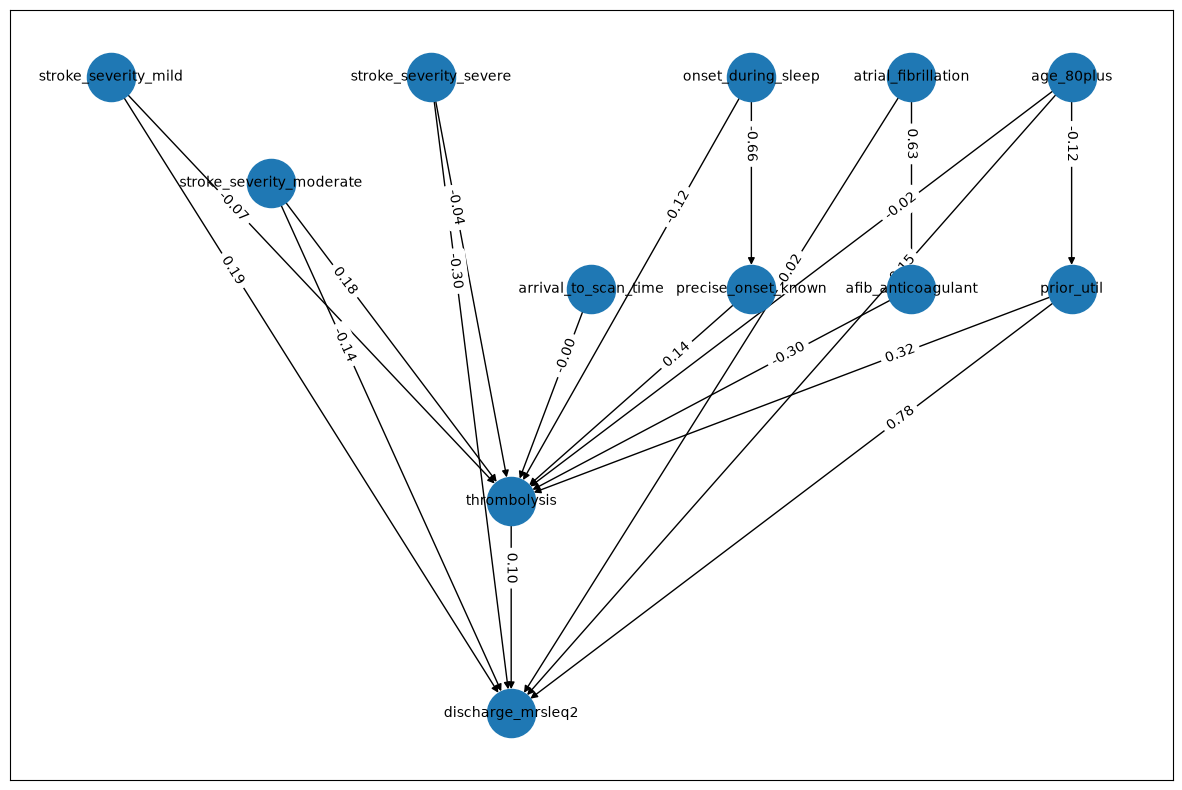

In [13]:
make_labelled_DAG(df_effects, df_edges)
plt.savefig("final_results_11_08_labelled_DAG.png")
plt.show()